###   AI FOR GEOLOGICAL ENGINEERING
# SLOPE FAILURE RISK PREDICTION

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("Geotechnical.csv")
df.head()

,Rock_Type,Depth_m,Porosity_percent,Permeability_mD,Uniaxial_Compressive_Strength_MPa,Youngs_Modulus_GPa,Slope_Angle_deg,Water_Table_Depth_m,Seismic_Velocity_mps,Slope_Failure_Risk
0,Shale,257.57,10.44,9.73,166.55,68.44,15.67,8.20,3604.57,0
1,Basalt,414.96,22.49,52.13,52.14,51.02,30.18,17.79,4287.25,1
2,Granite,166.82,17.64,15.92,260.84,11.65,46.89,43.37,3350.36,1
3,Basalt,448.81,31.78,16.46,222.39,41.57,45.23,8.59,3423.69,1
4,Basalt,200.71,29.52,25.06,38.95,10.82,31.14,5.05,2986.28,2


In [3]:
label_encoder = LabelEncoder()
df["Rock_Type"] = label_encoder.fit_transform(df["Rock_Type"])

In [4]:
x = df.drop("Slope_Failure_Risk",axis=1)
y = df["Slope_Failure_Risk"]

In [6]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size = 0.2,random_state =42,stratify=y)


In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

In [9]:
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [12]:
y_pred = model.predict(x_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

In [14]:
round(accuracy * 100, 2)

69.0

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.68      0.73        40
           1       0.63      0.83      0.72        48
           2       0.67      0.17      0.27        12

    accuracy                           0.69       100
   macro avg       0.70      0.56      0.57       100
weighted avg       0.70      0.69      0.67       100



In [16]:
cm = confusion_matrix(y_test, y_pred)

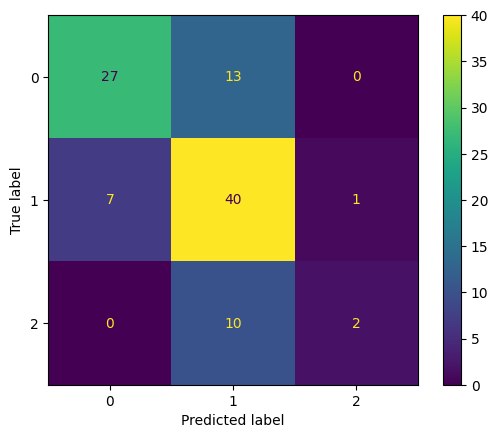

In [20]:
dis = ConfusionMatrixDisplay(confusion_matrix=cm)
dis.plot()
plt.show()


In [25]:
feature_importances = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print(feature_importances)

Uniaxial_Compressive_Strength_MPa    0.235667
Slope_Angle_deg                      0.150329
Water_Table_Depth_m                  0.123398
Seismic_Velocity_mps                 0.103006
Depth_m                              0.092772
Porosity_percent                     0.091597
Youngs_Modulus_GPa                   0.088684
Permeability_mD                      0.074216
Rock_Type                            0.040331
dtype: float64
